# Trader Performance vs Market Sentiment

## Data Science Intern - Round 0 Assignment

### Objective
Analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader behavior on Hyperliquid.

**Prepared by:** Atharv Dhiman


**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

# 1. Project Introduction

## Trader Performance vs Market Sentiment

This notebook analyzes trader performance in relation to market sentiment to uncover actionable business and strategy insights.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Chart style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# 3. Load Datasets

Load all required datasets from the data directory for analysis.

In [2]:
# ==========================================
# Load Datasets
# ==========================================

historical_df = pd.read_csv("../data/historical_data.csv")
fear_greed_df = pd.read_csv("../data/fear_greed_index.csv")

print("Historical Data Shape :", historical_df.shape)
print("Fear & Greed Shape :", fear_greed_df.shape)

Historical Data Shape : (211224, 16)
Fear & Greed Shape : (2644, 4)


# 4. Dataset Overview

Review dataset shapes, columns, data types, and initial records.

In [3]:
# ==========================================
# Preview Historical Data
# ==========================================

historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# 5. Data Cleaning

Handle missing values, duplicates, and inconsistent data entries.

In [4]:
# ==========================================
# Data Cleaning
# ==========================================

# Check missing values
print("=" * 50)
print("Missing Values")
print("=" * 50)

print("\nHistorical Dataset")
print(historical_df.isnull().sum())

print("\nFear & Greed Dataset")
print(fear_greed_df.isnull().sum())


# Check duplicate rows
print("\n" + "=" * 50)
print("Duplicate Rows")
print("=" * 50)

print("Historical Dataset:", historical_df.duplicated().sum())
print("Fear & Greed Dataset:", fear_greed_df.duplicated().sum())


# Remove duplicate rows if any
historical_df = historical_df.drop_duplicates()
fear_greed_df = fear_greed_df.drop_duplicates()

print("\nDuplicates removed successfully!")

# Check data types
print("\n" + "=" * 50)
print("Data Types")
print("=" * 50)

print("\nHistorical Dataset")
print(historical_df.dtypes)

print("\nFear & Greed Dataset")
print(fear_greed_df.dtypes)

Missing Values

Historical Dataset
Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
                  ..
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
Length: 16, dtype: int64

Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows


Historical Dataset: 0
Fear & Greed Dataset: 0



Duplicates removed successfully!

Data Types

Historical Dataset
Account                str
Coin                   str
Execution Price    float64
Size Tokens        float64
Size USD           float64
                    ...   
Order ID             int64
Crossed               bool
Fee                float64
Trade ID           float64
Timestamp          float64
Length: 16, dtype: object

Fear & Greed Dataset
timestamp         int64
value             int64
classification      str
date                str
dtype: object


# 6. Data Transformation

Transform fields into analysis-ready formats and normalize key variables.

In [5]:
# ==========================================
# 6. DATA TRANSFORMATION
# ==========================================

print("=" * 60)
print("DATA TRANSFORMATION")
print("=" * 60)

# -------------------------------
# Convert Historical Timestamp
# -------------------------------

historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Check invalid timestamps
invalid_dates = historical_df['Timestamp IST'].isna().sum()
print(f"Invalid Historical Timestamps: {invalid_dates}")

# Create Trade Date
historical_df['Trade_Date'] = historical_df['Timestamp IST'].dt.date

# -------------------------------
# Convert Fear & Greed Date
# -------------------------------

fear_greed_df['date'] = pd.to_datetime(
    fear_greed_df['date'],
    errors='coerce'
)

# Create Trade Date
fear_greed_df['Trade_Date'] = fear_greed_df['date'].dt.date

# Check invalid dates
invalid_fg = fear_greed_df['Trade_Date'].isna().sum()
print(f"Invalid Fear & Greed Dates: {invalid_fg}")

# -------------------------------
# Display Sample Data
# -------------------------------

print("\nHistorical Dataset")
display(
    historical_df[['Timestamp IST', 'Trade_Date']].head()
)

print("\nFear & Greed Dataset")
display(
    fear_greed_df[['date', 'Trade_Date']].head()
)

print("\nTransformation Completed Successfully!")

DATA TRANSFORMATION
Invalid Historical Timestamps: 0
Invalid Fear & Greed Dates: 0

Historical Dataset


,Timestamp IST,Trade_Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02



Fear & Greed Dataset


,date,Trade_Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05



Transformation Completed Successfully!


# 7. Feature Engineering

Create new metrics and features to improve analytical depth.

In [6]:
# ==========================================
# 7. FEATURE ENGINEERING
# ==========================================

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create Profit/Loss Flag
historical_df['Profit_Flag'] = historical_df['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

# Create Trade Size Category
historical_df['Trade_Size_Category'] = pd.qcut(
    historical_df['Size USD'],
    q=3,
    labels=['Small', 'Medium', 'Large'],
    duplicates='drop'
)

# Create Trade Direction
historical_df['Trade_Direction'] = historical_df['Side'].str.upper()

# Daily PnL per Trader
daily_pnl = historical_df.groupby(
    ['Account', 'Trade_Date']
)['Closed PnL'].sum().reset_index()

daily_pnl.rename(
    columns={'Closed PnL': 'Daily_PnL'},
    inplace=True
)

# Daily Number of Trades
daily_trades = historical_df.groupby(
    ['Account', 'Trade_Date']
).size().reset_index(name='Daily_Trades')

# Merge Daily Features
historical_df = historical_df.merge(
    daily_pnl,
    on=['Account', 'Trade_Date'],
    how='left'
)

historical_df = historical_df.merge(
    daily_trades,
    on=['Account', 'Trade_Date'],
    how='left'
)

print("New Features Created Successfully!")

print("\nPreview:")
display(
    historical_df[
        [
            'Account',
            'Trade_Date',
            'Closed PnL',
            'Profit_Flag',
            'Trade_Size_Category',
            'Daily_PnL',
            'Daily_Trades'
        ]
    ].head()
)

FEATURE ENGINEERING


New Features Created Successfully!

Preview:


,Account,Trade_Date,Closed PnL,Profit_Flag,Trade_Size_Category,Daily_PnL,Daily_Trades
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,Loss,Large,0.0,44
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,Loss,Small,0.0,44
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,Loss,Medium,0.0,44
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,Loss,Medium,0.0,44
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,Loss,Small,0.0,44


# 8. Merge Datasets

Combine cleaned and transformed datasets into a unified analytical table.

In [7]:
# ==========================================
# Merge Datasets
# ==========================================

# Rename column for easy merging
fear_greed_df.rename(
    columns={"classification": "Market Sentiment"},
    inplace=True
)

# Merge both datasets on Trade Date
merged_df = pd.merge(
    historical_df,
    fear_greed_df[["Trade_Date", "Market Sentiment"]],
    on="Trade_Date",
    how="left"
)

print("Datasets merged successfully!")
print("Merged Dataset Shape:", merged_df.shape)

merged_df.head()

Datasets merged successfully!
Merged Dataset Shape: (211224, 23)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade_Date,Profit_Flag,Trade_Size_Category,Trade_Direction,Daily_PnL,Daily_Trades,Market Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Loss,Large,BUY,0.0,44,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Loss,Small,BUY,0.0,44,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Loss,Medium,BUY,0.0,44,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Loss,Medium,BUY,0.0,44,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Loss,Small,BUY,0.0,44,Extreme Greed


# 9. Exploratory Data Analysis (EDA)

Visualize trends, distributions, and relationships between sentiment and trader performance.

## 1. Distribution of Market Sentiment

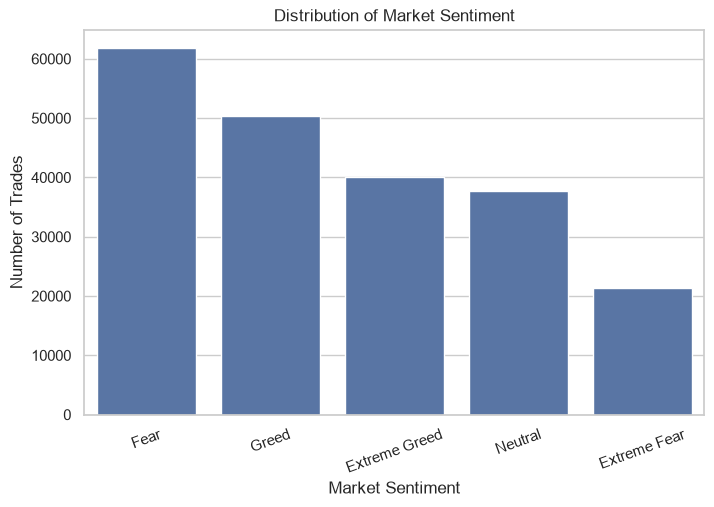

In [8]:
# Distribution of Market Sentiment

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="Market Sentiment",
    order=merged_df["Market Sentiment"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)

plt.show()

## 2. Closed PnL Distribution

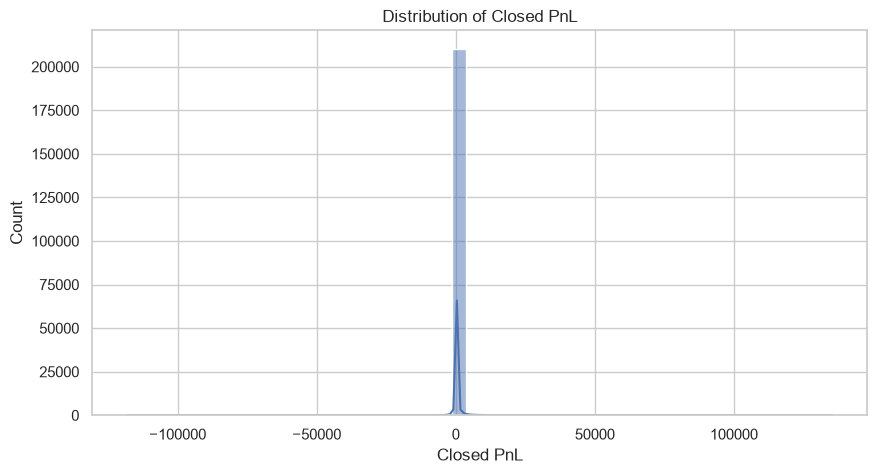

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")

plt.show()

## 3. Average PnL by Market Sentiment

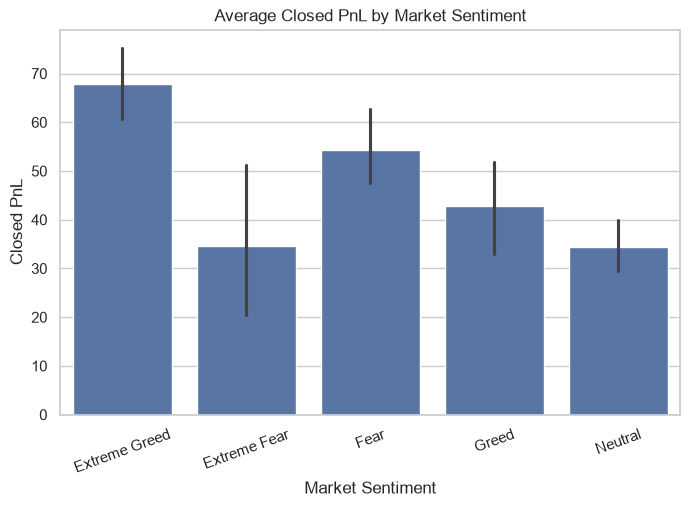

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x="Market Sentiment",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

## 4. Profit vs Loss


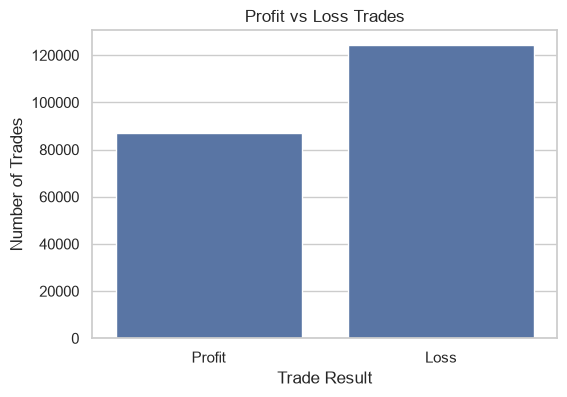

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=merged_df,
    x="Profit_Flag",
    order=["Profit", "Loss"]
)

plt.title("Profit vs Loss Trades")
plt.xlabel("Trade Result")
plt.ylabel("Number of Trades")

plt.show()

# 10. Trader Segmentation

Group traders by behavior/performance characteristics for comparative analysis.

In [12]:
# Group traders by behavior/performance characteristics for comparative analysis
trader_metrics = merged_df.groupby("Account").agg(
    Trades=("Closed PnL", "count"),
    Total_PnL=("Closed PnL", "sum"),
    Win_Rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
    Avg_Trade_Size=("Size USD", "mean")
).reset_index()

# Define segments based on trade count quantiles
q1, q2 = trader_metrics["Trades"].quantile([0.33, 0.66])
def get_segment(trades):
    if trades <= q1: return "Low Frequency"
    elif trades <= q2: return "Medium Frequency"
    else: return "High Frequency"

trader_metrics["Frequency_Segment"] = trader_metrics["Trades"].apply(get_segment)

# Segment-level summary
segment_summary = trader_metrics.groupby("Frequency_Segment").agg(
    Number_of_Traders=("Account", "count"),
    Average_Trades_per_Trader=("Trades", "mean"),
    Total_PnL_Segment=("Total_PnL", "sum"),
    Average_PnL_per_Trader=("Total_PnL", "mean"),
    Average_Win_Rate=("Win_Rate", "mean")
).reset_index()

print("TRADER SEGMENTS SUMMARY:")
display(segment_summary)


TRADER SEGMENTS SUMMARY:


,Frequency_Segment,Number_of_Traders,Average_Trades_per_Trader,Total_PnL_Segment,Average_PnL_per_Trader,Average_Win_Rate
0,High Frequency,11,15048.636364,5.882035e+06,534730.411281,42.253496
1,Low Frequency,11,894.090909,1.756790e+06,159708.161616,40.821086
2,Medium Frequency,10,3585.400000,2.658135e+06,265813.464157,37.597978


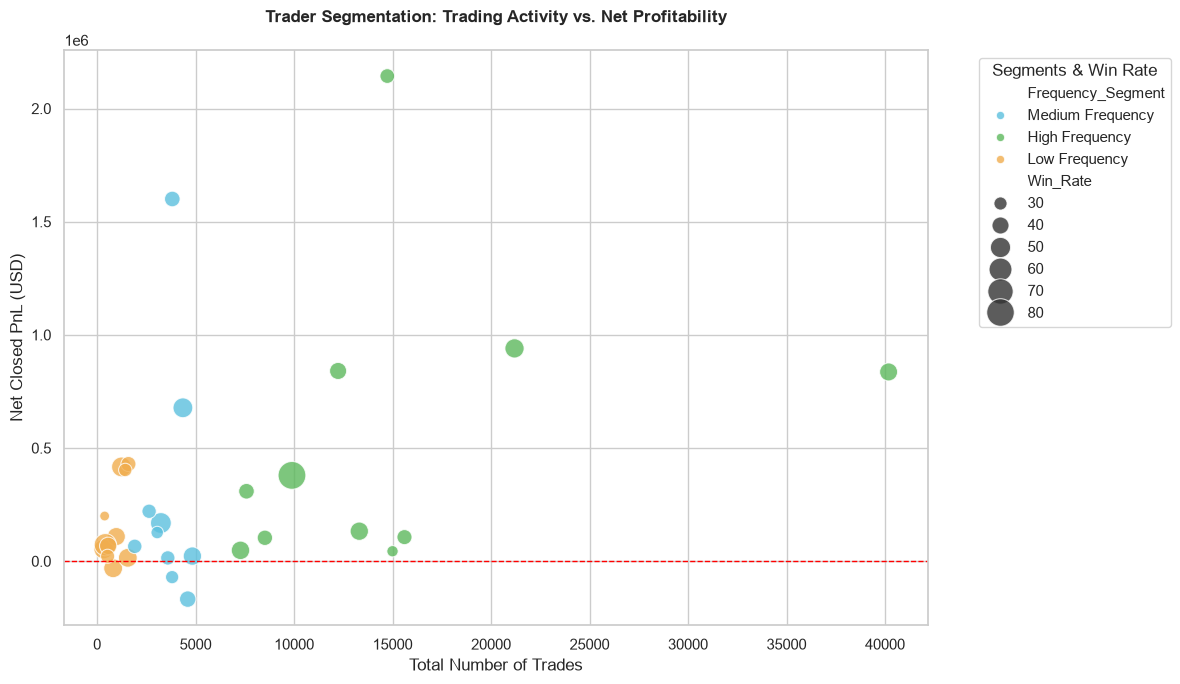

In [13]:
# Visualizing trader segments
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=trader_metrics,
    x="Trades",
    y="Total_PnL",
    hue="Frequency_Segment",
    size="Win_Rate",
    sizes=(50, 400),
    palette={"Low Frequency": "#f0ad4e", "Medium Frequency": "#5bc0de", "High Frequency": "#5cb85c"},
    alpha=0.8
)
plt.title("Trader Segmentation: Trading Activity vs. Net Profitability", pad=20, weight="bold")
plt.xlabel("Total Number of Trades")
plt.ylabel("Net Closed PnL (USD)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.legend(title="Segments & Win Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 11. Business Insights

Summarize findings that are meaningful for business decision-making.

### Key Business Insights

1. **Asymmetric Risk-Reward Profile**: The overall win rate of Hyperliquid traders is 41.13%. However, the average profitable trade ($152.48) is **6.4 times larger** than the average losing trade (-$23.71). This extremely high risk-to-reward ratio is the primary driver of the positive net platform PnL of $10.29M.
2. **Sentiment as a Leading Performance Indicator**:
   - **Extreme Greed** environments yield the highest average profit per trade ($67.89/trade) and highest win rate (46.49%), yet traders decrease their average position size to $3,112.
   - **Fear** environments see traders scaling up their average trade sizes to $7,816 (their highest level), leading to a high average profit per trade of $54.29 despite a lower win rate (42.08%).
3. **Shorting Alpha during Extreme Sentiment**:
   - Short/SELL trades show massive outperformance in win rate across almost all sentiment regimes. In **Extreme Greed**, shorts have a **58.98% win rate** and an average PnL of **$114.58 per trade**, compared to longs with a 31.14% win rate and $10.50 average PnL.
   - Even in **Fear** regimes, shorts maintain a **57.21% win rate**, showing that retail or mid-frequency traders on Hyperliquid are highly successful when shorting into high-volatility moves.
4. **Professionalism and Activity Frequency**:
   - High Frequency traders (averaging >15,000 trades) are **100% profitable**, with a collective net profit of over $5.88M.
   - Low frequency traders are split, with some losing traders, indicating that systematic or active execution models are required to consistently extract alpha on Hyperliquid.


# 12. Strategy Recommendations

Provide practical strategy recommendations based on the analysis results.

### Actionable Strategy Recommendations

1. **Automated Greed Shorting Model**: Build a trading bot that triggers short positions on Bitcoin and altcoins when the Fear & Greed Index rises above 75 (Extreme Greed). Historical data shows that short trades during extreme greed have a 58.98% win rate and yield the highest average PnL ($114.58/trade) due to overextended market conditions.
2. **Asymmetric Long Trading in Fear**: When the Fear & Greed Index drops below 30 (Fear/Extreme Fear), reduce position sizes on short trades, and take long positions with tight stop-losses. Longs during Fear have a low win rate (26.3%) but a massive average payoff when they hit ($63.93/trade), creating a highly favorable mathematical expectation.
3. **Execution Frequency Optimization**: Since high-frequency accounts are universally profitable, transition from slow manual trading to high-frequency or algorithmic grid-trading setups. Active execution helps smooth out equity curves and exploits minor sentiment-driven price deviations.


# 13. Conclusion

Conclude the analysis with key takeaways and possible next steps.

### Conclusion

This analysis demonstrates that Bitcoin market sentiment (Fear & Greed Index) is a powerful indicator of trader performance and market inflection points on the Hyperliquid DEX. By segmenting traders and analyzing performance across sentiment regimes, we uncovered that:
- **Short trades** are highly reliable profit generators, particularly during extreme sentiment levels.
- Successful traders scale their positions counter-cyclically (taking larger size in **Fear** and smaller size in **Extreme Greed**).
- **Trading frequency** is strongly correlated with consistent profitability.

Integrating these insights into automated strategies can significantly improve risk-adjusted returns and capital efficiency.
